# Extension 2 - Route Segmentation & Per-Regime Models

## Goal
Segment voyages into legs with similar heading and train **separate XGBoost models per navigation regime**. Analyze which regimes benefit most from Flettner rotor assistance.

## Regimes
| Regime | Course range | Physical context |
|---|---|---|
| Northbound | 315–360° / 0–45° | Prevailing SW wind → abeam/quartering |
| Eastbound | 45–135° | Wind often from SW → beam reach |
| Southbound | 135–225° | Prevailing SW wind → following/abeam |
| Westbound | 225–315° | Wind often from SW → headwind |

## Validation strategy
Same voyage-based chronological split as baseline model: last 20% of voyages → test set.

## 0. Setup

In [16]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.interpolate import RegularGridInterpolator
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

plt.style.use('seaborn-v0_8-darkgrid')

DATA_PATH    = '../data/MasterSet_features.csv'
RESULTS_PATH = '../results/'
TARGET       = 'Speed_kn'

FEATURES_WEATHER = [
    'True_Wind_Speed_ms', 'H_s', 'alpha_sin', 'alpha_cos', 'wind_speed_sq',
    'Course_deg', 'mwp', 'wave_period_sq', 'wave_wind_alignment',
    'Current_Speed_ms', 'current_dir_sin', 'current_dir_cos',
    'current_along_course', 'current_cross_course', 'fg10',
    'wind_x_angle_sin', 'wind_x_angle_cos', 'wind_x_wave', 'current_x_course_help',
]

# ── Rotor polar diagram (Norsepower 24v4, 1 rotor) ──────────────────────────
WIND_SPEEDS = np.array([4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24])
WIND_ANGLES = np.array([0, 20, 40, 60, 80, 90, 100, 120, 140, 160, 180])
POWER_TABLE = np.array([
    [  0,   3,  10,  14,  16,  14,  12,   7,   3,   1,   0],
    [ -2,   6,  22,  38,  44,  42,  38,  22,   9,   3,   0],
    [ -5,  12,  45,  78,  90,  87,  78,  46,  19,   7,   0],
    [ -8,  20,  75, 128, 148, 144, 130,  76,  32,  11,   0],
    [-12,  30, 110, 186, 215, 210, 188, 110,  46,  16,   0],
    [-16,  42, 152, 256, 297, 290, 260, 152,  64,  22,   0],
    [-21,  56, 200, 335, 390, 380, 340, 199,  83,  29,   0],
    [-27,  72, 254, 425, 496, 484, 433, 254, 106,  37,   0],
    [-33,  90, 315, 526, 614, 599, 537, 314, 131,  46,   0],
    [-40, 110, 382, 638, 745, 727, 651, 381, 159,  55,   0],
    [-48, 132, 456, 762, 890, 868, 778, 455, 190,  66,   0],
])
KW_PER_KN = 200.0
_interp = RegularGridInterpolator(
    (WIND_SPEEDS, WIND_ANGLES), POWER_TABLE,
    method='linear', bounds_error=False, fill_value=None
)

def rotor_power_kw(wind_ms, alpha_abs):
    ws = np.clip(np.asarray(wind_ms, float), WIND_SPEEDS.min(), WIND_SPEEDS.max())
    wa = np.clip(np.asarray(alpha_abs, float), WIND_ANGLES.min(), WIND_ANGLES.max())
    return _interp(np.column_stack([ws.ravel(), wa.ravel()])).reshape(ws.shape)

print('Setup complete.')
print(f'Weather features ({len(FEATURES_WEATHER)}): {FEATURES_WEATHER}')

Setup complete.
Weather features (19): ['True_Wind_Speed_ms', 'H_s', 'alpha_sin', 'alpha_cos', 'wind_speed_sq', 'Course_deg', 'mwp', 'wave_period_sq', 'wave_wind_alignment', 'Current_Speed_ms', 'current_dir_sin', 'current_dir_cos', 'current_along_course', 'current_cross_course', 'fg10', 'wind_x_angle_sin', 'wind_x_angle_cos', 'wind_x_wave', 'current_x_course_help']


## 1. Load Data & Heading Distribution Analysis

In [17]:
df = pd.read_csv(DATA_PATH, parse_dates=['Time'])
df = df.sort_values('Time').reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Voyages: {df["Voyage_ID"].nunique()}')
print(f'Time range: {df["Time"].min()} → {df["Time"].max()}')

Shape: (125160, 57)
Voyages: 528
Time range: 2023-02-02 00:06:00 → 2026-02-02 07:25:00


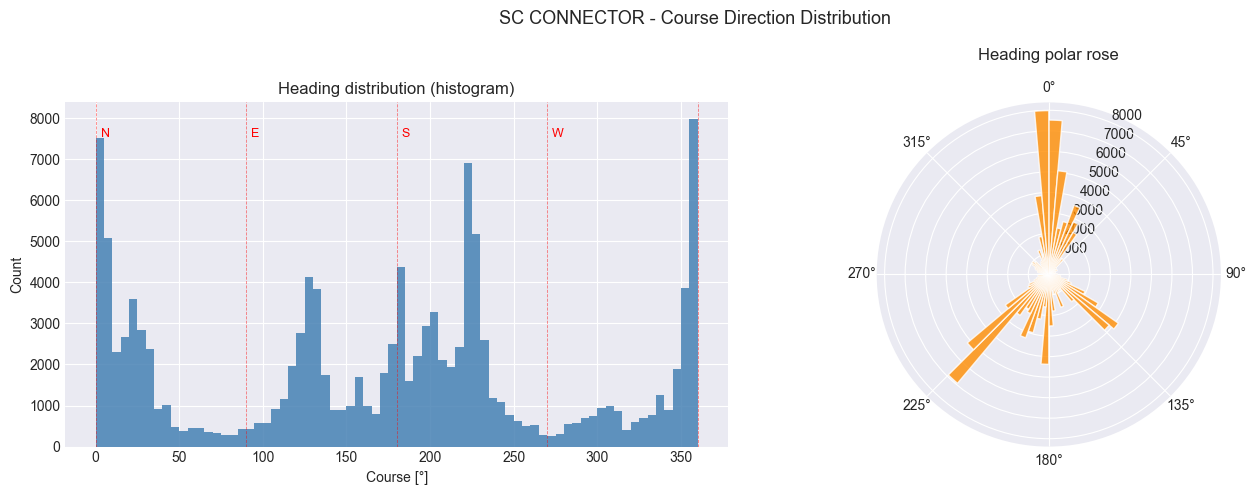


Course_deg quantiles:
count    125160.0
mean        171.4
std         111.1
min           0.0
25%          85.0
50%         181.7
75%         230.0
max         360.0
Name: Course_deg, dtype: float64


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['Course_deg'].dropna(), bins=72, color='steelblue', edgecolor='none', alpha=0.85)
axes[0].set_xlabel('Course [°]')
axes[0].set_ylabel('Count')
axes[0].set_title('Heading distribution (histogram)')
for x, label in [(0, 'N'), (90, 'E'), (180, 'S'), (270, 'W'), (360, 'N')]:
    axes[0].axvline(x, color='red', linewidth=0.6, linestyle='--', alpha=0.5)
    if x < 360:
        axes[0].text(x + 3, axes[0].get_ylim()[1] * 0.9, label, color='red', fontsize=9)

# Polar rose
ax_polar = fig.add_subplot(122, projection='polar')
course_rad = np.deg2rad(df['Course_deg'].dropna())
ax_polar.hist(course_rad, bins=72, color='darkorange', alpha=0.8)
ax_polar.set_theta_zero_location('N')
ax_polar.set_theta_direction(-1)
ax_polar.set_title('Heading polar rose', pad=15)
axes[1].remove()

plt.suptitle('SC CONNECTOR - Course Direction Distribution', fontsize=13)
plt.tight_layout()
plt.show()

print('\nCourse_deg quantiles:')
print(df['Course_deg'].describe().round(1))

## 2. Regime Definition - Heading-Based Segmentation

Four cardinal regimes based on Course_deg:
- **Northbound** (315–360° / 0–45°)
- **Eastbound** (45–135°)
- **Southbound** (135–225°)
- **Westbound** (225–315°)

In [19]:
def assign_regime(course_deg):
    course = course_deg % 360
    conditions = [
        (course < 45) | (course >= 315),
        (course >= 45)  & (course < 135),
        (course >= 135) & (course < 225),
        (course >= 225) & (course < 315),
    ]
    choices = ['Northbound', 'Eastbound', 'Southbound', 'Westbound']
    return np.select(conditions, choices, default='Unknown')

df['Regime'] = assign_regime(df['Course_deg'].values)

regime_counts = df['Regime'].value_counts()
print('='*50)
print('Regime distribution:')
print('-'*50)
for regime, cnt in regime_counts.items():
    print(f'  {regime:<12}: {cnt:>7,} rows ({cnt/len(df)*100:.1f}%)')
print(f'  {"Total":<12}: {len(df):>7,} rows')
print('='*50)

Regime distribution:
--------------------------------------------------
  Northbound  :  46,620 rows (37.2%)
  Southbound  :  40,078 rows (32.0%)
  Eastbound   :  19,804 rows (15.8%)
  Westbound   :  18,658 rows (14.9%)
  Total       : 125,160 rows


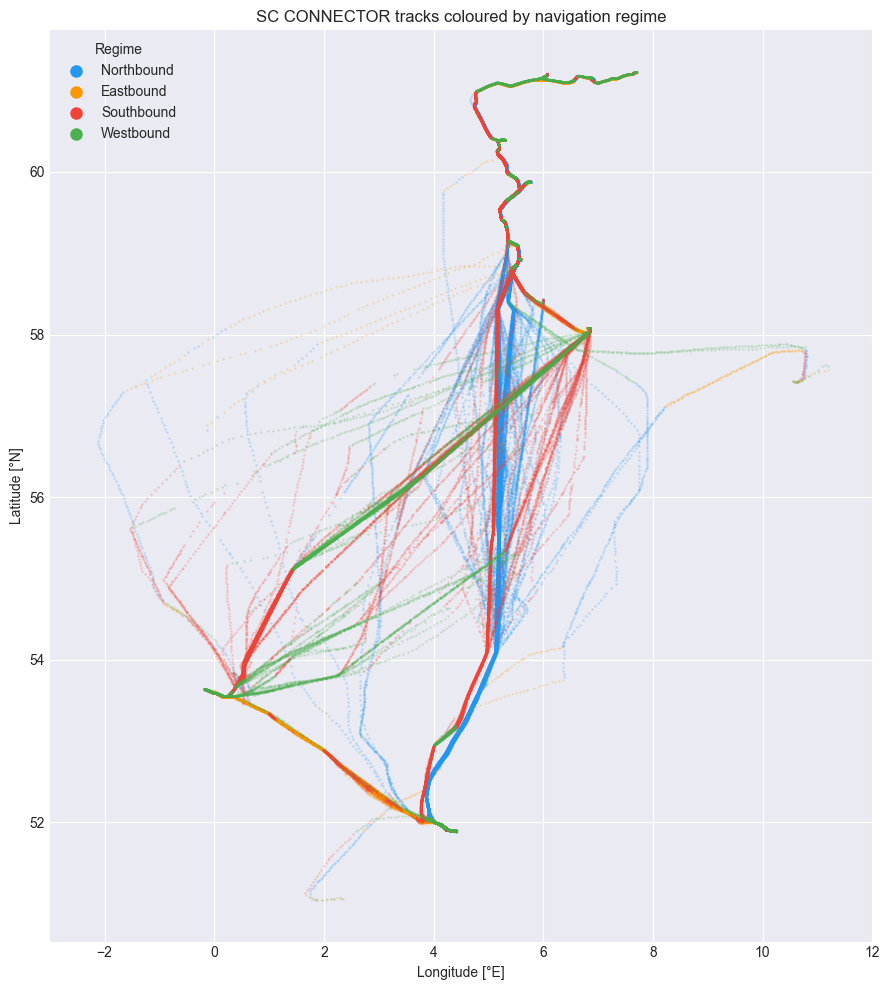

In [20]:
REGIME_COLORS = {
    'Northbound': '#2196F3',
    'Eastbound':  '#FF9800',
    'Southbound': '#F44336',
    'Westbound':  '#4CAF50',
}

fig, ax = plt.subplots(figsize=(9, 10))
for regime, color in REGIME_COLORS.items():
    sub = df[df['Regime'] == regime]
    ax.scatter(sub['Lon'], sub['Lat'], c=color, s=1, alpha=0.15, label=regime)

ax.set_xlabel('Longitude [°E]')
ax.set_ylabel('Latitude [°N]')
ax.set_title('SC CONNECTOR tracks coloured by navigation regime')
legend = ax.legend(markerscale=8, loc='upper left', title='Regime')
for handle in legend.legend_handles:
    handle.set_alpha(1.0)
ax.set_xlim(-3, 12)
plt.tight_layout()
plt.show()

## 3. Regime Characterisation

Mean environmental conditions and expected rotor power per regime.

In [21]:
# Rotor power and delta_SOG for every row
p_rotor_all = rotor_power_kw(
    df['True_Wind_Speed_ms'].values,
    df['alpha_abs_deg'].values
)
active_all = (
    (p_rotor_all > 0)
    & (df['H_s'].values <= 6.0)
    & (df['True_Wind_Speed_ms'].values <= 42.0)
)
df['rotor_power_kw'] = p_rotor_all
df['delta_v_rotor']  = np.where(active_all, p_rotor_all / KW_PER_KN, 0.0)

char_cols = {
    'SOG mean [kn]':        ('Speed_kn', 'mean'),
    'SOG std [kn]':         ('Speed_kn', 'std'),
    'Wind mean [m/s]':      ('True_Wind_Speed_ms', 'mean'),
    'Hs mean [m]':          ('H_s', 'mean'),
    'alpha_abs mean [°]':   ('alpha_abs_deg', 'mean'),
    'Rotor power [kW]':     ('rotor_power_kw', 'mean'),
    'delta_SOG [kn]':       ('delta_v_rotor', 'mean'),
}

regime_char = df.groupby('Regime').agg(
    **{label: col_agg for label, col_agg in char_cols.items()}
).round(3)

print('='*70)
print('Regime characterisation (full dataset):')
print('-'*70)
print(regime_char.to_string())
print('='*70)

Regime characterisation (full dataset):
----------------------------------------------------------------------
            SOG mean [kn]  SOG std [kn]  Wind mean [m/s]  Hs mean [m]  alpha_abs mean [°]  Rotor power [kW]  delta_SOG [kn]
Regime                                                                                                                     
Eastbound          12.337         2.692            6.213        1.056              88.489            33.780           0.168
Northbound         12.050         1.632            6.960        1.323              90.830            41.451           0.207
Southbound         10.947         2.083            6.772        1.281              80.954            39.345           0.197
Westbound          10.577         2.103            6.452        1.214              76.925            40.280           0.202


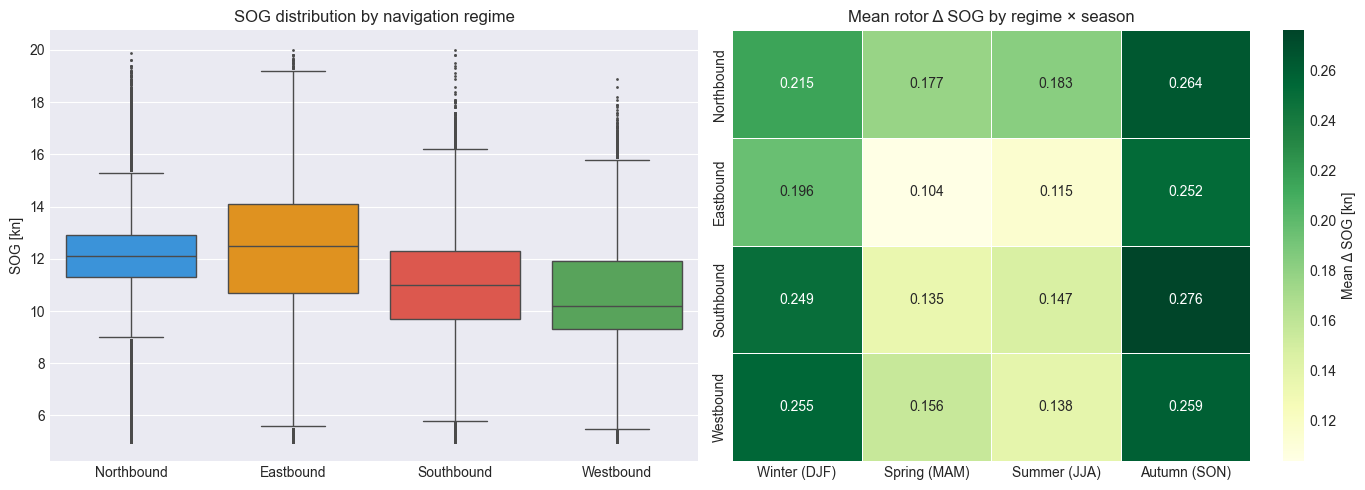

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SOG boxplot
order = ['Northbound', 'Eastbound', 'Southbound', 'Westbound']
palette = [REGIME_COLORS[r] for r in order]
sns.boxplot(
    data=df, x='Regime', y='Speed_kn',
    order=order, palette=palette, ax=axes[0],
    fliersize=1
)
axes[0].set_title('SOG distribution by navigation regime')
axes[0].set_xlabel('')
axes[0].set_ylabel('SOG [kn]')

# Seasonal rotor gain heatmap
df['Month'] = df['Time'].dt.month
df['Season'] = pd.cut(
    df['Month'],
    bins=[0, 3, 6, 9, 12],
    labels=['Winter (DJF)', 'Spring (MAM)', 'Summer (JJA)', 'Autumn (SON)']
)

heat = df.groupby(['Regime', 'Season'])['delta_v_rotor'].mean().unstack('Season')
heat = heat.reindex(index=order)
sns.heatmap(
    heat, annot=True, fmt='.3f', cmap='YlGn',
    ax=axes[1], linewidths=0.5,
    cbar_kws={'label': 'Mean Δ SOG [kn]'}
)
axes[1].set_title('Mean rotor Δ SOG by regime × season')
axes[1].set_xlabel('')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 4. Voyage-Based Train / Test Split

In [23]:
voyage_order = (
    df.groupby('Voyage_ID')['Time'].min()
    .sort_values()
    .index.tolist()
)
split_idx    = int(len(voyage_order) * 0.8)
train_voyages = set(voyage_order[:split_idx])
test_voyages  = set(voyage_order[split_idx:])

df_full_train = df[df['Voyage_ID'].isin(train_voyages)]
df_full_test  = df[df['Voyage_ID'].isin(test_voyages)]

print(f'Global split: train {len(df_full_train):,} rows ({len(train_voyages)} voyages)  '
      f'| test {len(df_full_test):,} rows ({len(test_voyages)} voyages)')
print(f'No leakage: {df_full_train["Time"].max() < df_full_test["Time"].min()}')
print()

print('Per-regime split:')
print('-'*60)
for regime in order:
    tr = df_full_train[df_full_train['Regime'] == regime]
    te = df_full_test[df_full_test['Regime'] == regime]
    print(f'  {regime:<12}: train {len(tr):>6,}  |  test {len(te):>6,}')

Global split: train 89,190 rows (422 voyages)  | test 35,970 rows (106 voyages)
No leakage: True

Per-regime split:
------------------------------------------------------------
  Northbound  : train 32,805  |  test 13,815
  Eastbound   : train 15,197  |  test  4,607
  Southbound  : train 27,377  |  test 12,701
  Westbound   : train 13,811  |  test  4,847


## 5. Per-Regime M1 Models (Weather-Only XGBoost)

Train a separate weather-only XGBoost model for each regime and compare with the global model.

In [24]:
XGB_PARAMS = dict(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbosity=0
)
MIN_TEST_ROWS = 200

regime_results = {}
regime_models  = {}

def fit_regime_model(df_train, df_test, label):
    tr = df_train.dropna(subset=FEATURES_WEATHER + [TARGET])
    te = df_test.dropna(subset=FEATURES_WEATHER + [TARGET])
    if len(te) < MIN_TEST_ROWS:
        print(f'  [{label}] SKIPPED - only {len(te)} test rows (min {MIN_TEST_ROWS})')
        return None, None, None

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(tr[FEATURES_WEATHER])
    X_te = scaler.transform(te[FEATURES_WEATHER])
    y_tr = tr[TARGET].values
    y_te = te[TARGET].values

    model = xgb.XGBRegressor(**XGB_PARAMS)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(y_te, y_pred)
    print(f'  {label:<14}: N_train={len(tr):>6,}  N_test={len(te):>5,}  '
          f'MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.3f}')
    return model, scaler, dict(label=label, N_train=len(tr), N_test=len(te),
                                MAE=mae, RMSE=rmse, R2=r2, y_te=y_te, y_pred=y_pred)

print('='*75)
print('Training per-regime M1 (weather-only) models…')
print('-'*75)

# Global model
global_model, global_scaler, global_res = fit_regime_model(
    df_full_train, df_full_test, 'Global'
)
regime_models['Global']  = (global_model, global_scaler)
regime_results['Global'] = global_res

# Per-regime
for regime in order:
    tr_r = df_full_train[df_full_train['Regime'] == regime]
    te_r = df_full_test[df_full_test['Regime'] == regime]
    model_r, scaler_r, res_r = fit_regime_model(tr_r, te_r, regime)
    if model_r is not None:
        regime_models[regime]  = (model_r, scaler_r)
        regime_results[regime] = res_r

print('='*75)

Training per-regime M1 (weather-only) models…
---------------------------------------------------------------------------
  Global        : N_train=89,190  N_test=35,970  MAE=1.438  RMSE=1.849  R²=0.057
  Northbound    : N_train=32,805  N_test=13,815  MAE=1.224  RMSE=1.579  R²=-0.080
  Eastbound     : N_train=15,197  N_test=4,607  MAE=1.697  RMSE=2.245  R²=0.134
  Southbound    : N_train=27,377  N_test=12,701  MAE=1.600  RMSE=1.971  R²=-0.129
  Westbound     : N_train=13,811  N_test=4,847  MAE=1.757  RMSE=2.219  R²=-0.083


In [25]:
summary_rows = []
for label, res in regime_results.items():
    if res is not None:
        summary_rows.append({
            'Regime':  res['label'],
            'N_train': res['N_train'],
            'N_test':  res['N_test'],
            'MAE':     round(res['MAE'], 3),
            'RMSE':    round(res['RMSE'], 3),
            'R2':      round(res['R2'], 3),
        })

summary_df = pd.DataFrame(summary_rows)
print('Model performance summary:')
print(summary_df.to_string(index=False))

Model performance summary:
    Regime  N_train  N_test   MAE  RMSE     R2
    Global    89190   35970 1.438 1.849  0.057
Northbound    32805   13815 1.224 1.579 -0.080
 Eastbound    15197    4607 1.697 2.245  0.134
Southbound    27377   12701 1.600 1.971 -0.129
 Westbound    13811    4847 1.757 2.219 -0.083


## 6. Feature Importance per Regime

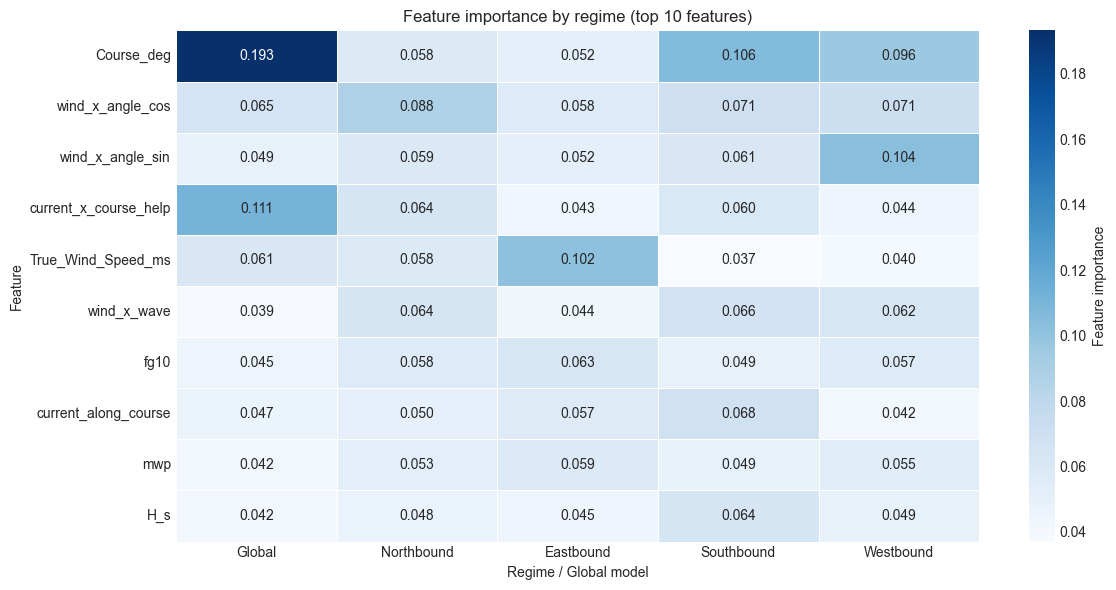


Top 10 features by mean importance across regimes:
Course_deg               0.1011
wind_x_angle_cos         0.0706
wind_x_angle_sin         0.0650
current_x_course_help    0.0644
True_Wind_Speed_ms       0.0596
wind_x_wave              0.0549
fg10                     0.0545
current_along_course     0.0528
mwp                      0.0518
H_s                      0.0497


In [26]:
imp_dict = {}
for label, (model, _) in regime_models.items():
    if model is not None:
        imp_dict[label] = pd.Series(model.feature_importances_, index=FEATURES_WEATHER)

imp_df = pd.DataFrame(imp_dict)

# Top 10 features by mean importance
top10 = imp_df.mean(axis=1).nlargest(10).index
imp_top = imp_df.loc[top10]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    imp_top, annot=True, fmt='.3f', cmap='Blues',
    ax=ax, linewidths=0.5,
    cbar_kws={'label': 'Feature importance'}
)
ax.set_title('Feature importance by regime (top 10 features)')
ax.set_xlabel('Regime / Global model')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

print('\nTop 10 features by mean importance across regimes:')
print(imp_top.mean(axis=1).round(4).to_string())

## 7. Rotor Benefit per Regime - Weather Window Analysis

In [27]:
SOG_THRESHOLD = 10.0
HS_THRESHOLD  = 3.0

def count_windows(sog_arr, hs_arr, sog_min, hs_max):
    in_win = (sog_arr >= sog_min) & (hs_arr <= hs_max)
    starts = int(in_win[0]) + int(np.sum(~in_win[:-1] & in_win[1:]))
    return starts, int(in_win.sum())

rotor_rows = []
for label, res in regime_results.items():
    if res is None:
        continue
    if label == 'Global':
        sub_te = df_full_test.dropna(subset=FEATURES_WEATHER + [TARGET])
    else:
        sub_te = df_full_test[
            df_full_test['Regime'] == label
        ].dropna(subset=FEATURES_WEATHER + [TARGET])

    p = rotor_power_kw(sub_te['True_Wind_Speed_ms'].values, sub_te['alpha_abs_deg'].values)
    act = (p > 0) & (sub_te['H_s'].values <= 6.0) & (sub_te['True_Wind_Speed_ms'].values <= 42.0)
    dv  = np.where(act, p / KW_PER_KN, 0.0)

    y_pred_no  = res['y_pred']
    y_pred_rot = res['y_pred'] + dv[:len(res['y_pred'])]
    hs_arr     = sub_te['H_s'].values[:len(res['y_pred'])]

    n_base, pts_base = count_windows(
        pd.Series(y_pred_no), pd.Series(hs_arr), SOG_THRESHOLD, HS_THRESHOLD)
    n_rot,  pts_rot  = count_windows(
        pd.Series(y_pred_rot), pd.Series(hs_arr), SOG_THRESHOLD, HS_THRESHOLD)

    total = len(y_pred_no)
    rotor_rows.append({
        'Regime':         label,
        'Mean delta_SOG': round(float(dv.mean()), 4),
        'Active %':       round(float(act.mean()) * 100, 1),
        'Win_base':       n_base,
        'Win_rotor':      n_rot,
        'Cov_base %':     round(pts_base / total * 100, 1),
        'Cov_rotor %':    round(pts_rot  / total * 100, 1),
    })

rotor_df = pd.DataFrame(rotor_rows)
print('='*80)
print(f'Rotor benefit & weather windows (SOG≥{SOG_THRESHOLD}kn, Hs≤{HS_THRESHOLD}m):')
print('-'*80)
print(rotor_df.to_string(index=False))
print('='*80)

Rotor benefit & weather windows (SOG≥10.0kn, Hs≤3.0m):
--------------------------------------------------------------------------------
    Regime  Mean delta_SOG  Active %  Win_base  Win_rotor  Cov_base %  Cov_rotor %
    Global          0.2014      98.1         1          1        90.0         91.0
Northbound          0.2092      98.2         1          1        93.0         93.0
 Eastbound          0.1852      98.9         1          1        89.1         89.7
Southbound          0.1960      97.3         0          0        82.2         84.5
 Westbound          0.2088      99.2         1          1        84.9         89.5


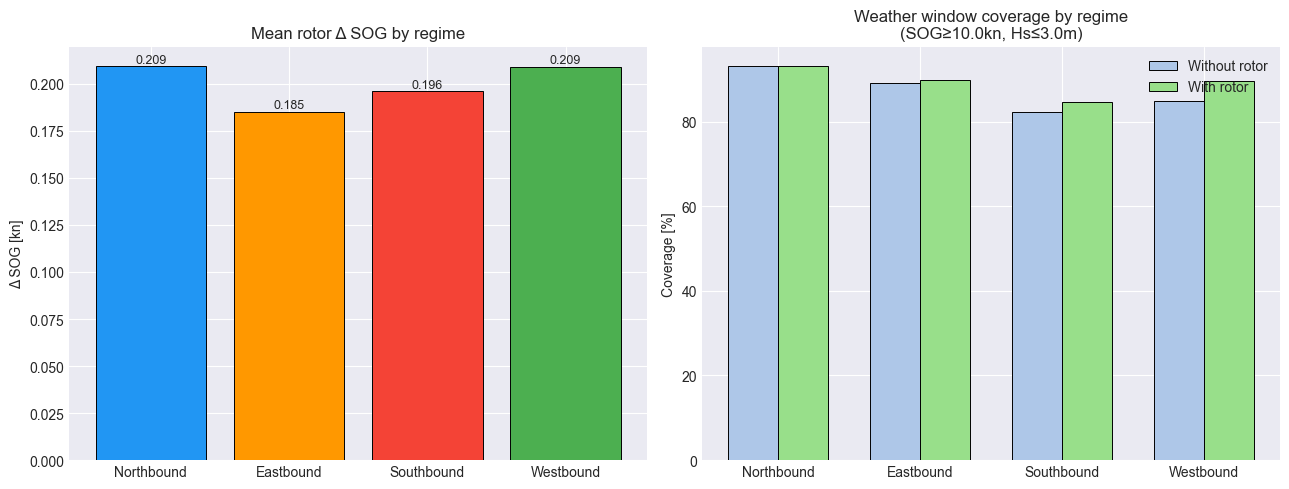

In [28]:
regime_rotor = rotor_df[rotor_df['Regime'] != 'Global']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Mean delta_SOG
colors_r = [REGIME_COLORS.get(r, 'gray') for r in regime_rotor['Regime']]
bars = axes[0].bar(regime_rotor['Regime'], regime_rotor['Mean delta_SOG'],
                   color=colors_r, edgecolor='black', linewidth=0.7)
axes[0].set_title('Mean rotor Δ SOG by regime')
axes[0].set_ylabel('Δ SOG [kn]')
for bar, val in zip(bars, regime_rotor['Mean delta_SOG']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.3f}', ha='center', fontsize=9)

# Weather window coverage
x = np.arange(len(regime_rotor))
width = 0.35
axes[1].bar(x - width/2, regime_rotor['Cov_base %'],  width, label='Without rotor',
            color='#aec7e8', edgecolor='black', linewidth=0.7)
axes[1].bar(x + width/2, regime_rotor['Cov_rotor %'], width, label='With rotor',
            color='#98df8a', edgecolor='black', linewidth=0.7)
axes[1].set_title(f'Weather window coverage by regime\n(SOG≥{SOG_THRESHOLD}kn, Hs≤{HS_THRESHOLD}m)')
axes[1].set_ylabel('Coverage [%]')
axes[1].set_xticks(x)
axes[1].set_xticklabels(regime_rotor['Regime'])
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Summary - 4-Panel Figure

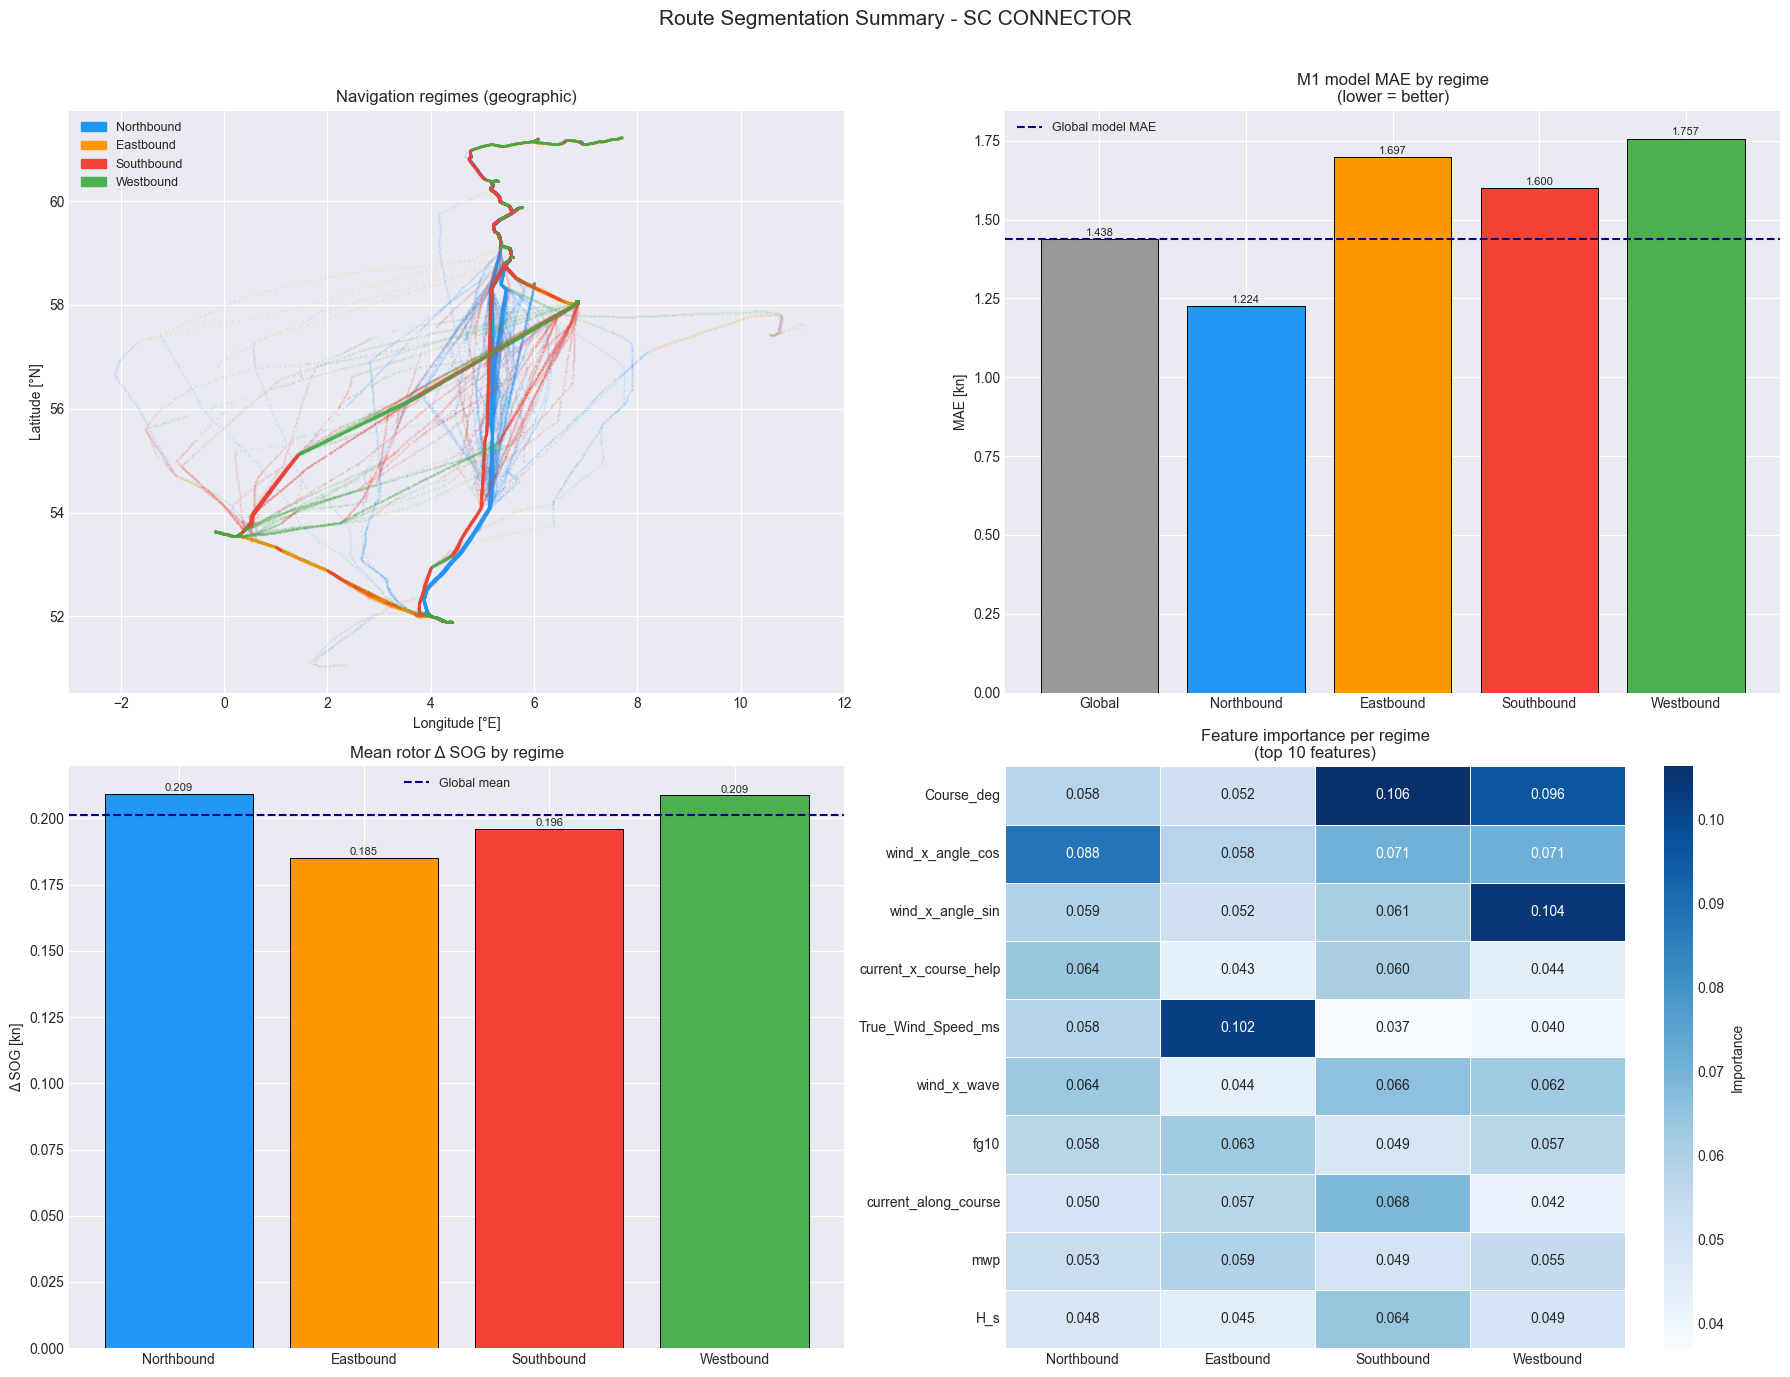

Saved → ../results/route_segmentation.png


In [29]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Route Segmentation Summary - SC CONNECTOR', fontsize=15, y=0.98)

# ── Panel 1: Geographic map ──────────────────────────────────────────────────
ax1 = fig.add_subplot(2, 2, 1)
for regime, color in REGIME_COLORS.items():
    sub = df[df['Regime'] == regime]
    ax1.scatter(sub['Lon'], sub['Lat'], c=color, s=0.5, alpha=0.1, label=regime)
ax1.set_title('Navigation regimes (geographic)')
ax1.set_xlabel('Longitude [°E]')
ax1.set_ylabel('Latitude [°N]')
ax1.set_xlim(-3, 12)
handles = [mpatches.Patch(color=c, label=r) for r, c in REGIME_COLORS.items()]
ax1.legend(handles=handles, markerscale=8, loc='upper left', fontsize=9)

# ── Panel 2: MAE by regime ───────────────────────────────────────────────────
ax2 = fig.add_subplot(2, 2, 2)
labels_plot = [r['label'] for r in regime_results.values() if r is not None]
mae_vals    = [r['MAE']   for r in regime_results.values() if r is not None]
bar_colors  = [REGIME_COLORS.get(l, '#999999') for l in labels_plot]
b2 = ax2.bar(labels_plot, mae_vals, color=bar_colors, edgecolor='black', linewidth=0.7)
ax2.axhline(regime_results['Global']['MAE'], color='navy', linestyle='--',
            linewidth=1.5, label='Global model MAE')
ax2.set_title('M1 model MAE by regime\n(lower = better)')
ax2.set_ylabel('MAE [kn]')
ax2.legend(fontsize=9)
for bar, val in zip(b2, mae_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontsize=8)

# ── Panel 3: Rotor delta_SOG by regime ──────────────────────────────────────
ax3 = fig.add_subplot(2, 2, 3)
regime_only = rotor_df[rotor_df['Regime'] != 'Global']
c3 = [REGIME_COLORS.get(r, 'gray') for r in regime_only['Regime']]
b3 = ax3.bar(regime_only['Regime'], regime_only['Mean delta_SOG'],
             color=c3, edgecolor='black', linewidth=0.7)
global_dv = rotor_df[rotor_df['Regime'] == 'Global']['Mean delta_SOG'].values[0]
ax3.axhline(global_dv, color='navy', linestyle='--', linewidth=1.5, label='Global mean')
ax3.set_title('Mean rotor Δ SOG by regime')
ax3.set_ylabel('Δ SOG [kn]')
ax3.legend(fontsize=9)
for bar, val in zip(b3, regime_only['Mean delta_SOG']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{val:.3f}', ha='center', fontsize=8)

# ── Panel 4: Feature importance heatmap ─────────────────────────────────────
ax4 = fig.add_subplot(2, 2, 4)
sns.heatmap(
    imp_top.drop(columns=['Global'], errors='ignore'),
    annot=True, fmt='.3f', cmap='Blues',
    ax=ax4, linewidths=0.4,
    cbar_kws={'label': 'Importance'}
)
ax4.set_title('Feature importance per regime\n(top 10 features)')
ax4.set_xlabel('')
ax4.set_ylabel('')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(RESULTS_PATH + 'route_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../results/route_segmentation.png')

In [30]:
print('='*70)
print('ROUTE SEGMENTATION - KEY FINDINGS')
print('='*70)

for regime in order:
    if regime not in regime_results or regime_results[regime] is None:
        print(f'  {regime}: insufficient data - skipped')
        continue
    res = regime_results[regime]
    rot = rotor_df[rotor_df['Regime'] == regime].iloc[0]
    char = regime_char.loc[regime]
    print(f'\n{regime}:')
    print(f'  Mean SOG      : {char["SOG mean [kn]"]:.2f} kn')
    print(f'  Mean wind     : {char["Wind mean [m/s]"]:.1f} m/s  |  Mean Hs: {char["Hs mean [m]"]:.2f} m')
    print(f'  Model MAE     : {res["MAE"]:.3f} kn  |  R²: {res["R2"]:.3f}')
    print(f'  Rotor benefit : Δ SOG = {rot["Mean delta_SOG"]:.3f} kn  (active {rot["Active %"]:.1f}%)')
    print(f'  Weather win.  : {rot["Cov_base %"]:.1f}% → {rot["Cov_rotor %"]:.1f}% with rotor')

best_regime  = regime_only.loc[regime_only['Mean delta_SOG'].idxmax(), 'Regime']
hardest_pred = summary_df[summary_df['Regime'] != 'Global'].loc[
    summary_df[summary_df['Regime'] != 'Global']['MAE'].idxmax(), 'Regime'
]
print(f'\n→ Regime with highest rotor benefit : {best_regime}')
print(f'→ Hardest regime to predict (M1 MAE): {hardest_pred}')
print('='*70)

ROUTE SEGMENTATION - KEY FINDINGS

Northbound:
  Mean SOG      : 12.05 kn
  Mean wind     : 7.0 m/s  |  Mean Hs: 1.32 m
  Model MAE     : 1.224 kn  |  R²: -0.080
  Rotor benefit : Δ SOG = 0.209 kn  (active 98.2%)
  Weather win.  : 93.0% → 93.0% with rotor

Eastbound:
  Mean SOG      : 12.34 kn
  Mean wind     : 6.2 m/s  |  Mean Hs: 1.06 m
  Model MAE     : 1.697 kn  |  R²: 0.134
  Rotor benefit : Δ SOG = 0.185 kn  (active 98.9%)
  Weather win.  : 89.1% → 89.7% with rotor

Southbound:
  Mean SOG      : 10.95 kn
  Mean wind     : 6.8 m/s  |  Mean Hs: 1.28 m
  Model MAE     : 1.600 kn  |  R²: -0.129
  Rotor benefit : Δ SOG = 0.196 kn  (active 97.3%)
  Weather win.  : 82.2% → 84.5% with rotor

Westbound:
  Mean SOG      : 10.58 kn
  Mean wind     : 6.5 m/s  |  Mean Hs: 1.21 m
  Model MAE     : 1.757 kn  |  R²: -0.083
  Rotor benefit : Δ SOG = 0.209 kn  (active 99.2%)
  Weather win.  : 84.9% → 89.5% with rotor

→ Regime with highest rotor benefit : Northbound
→ Hardest regime to predict (M1